# Pre-exploration of the count data 
This jupiter notebook help us to explore the count matrix in order to preprocess the count data and clean the low counts in order to reduce the noise in the diferential expression analisis

In [1]:
from sklearn.decomposition import PCA 
import seaborn as sns 
import matplotlib.pyplot as plt  
import numpy as np 
import pandas as pd 
import scanpy as sc
import os

In [2]:
#chargue of the both data
raw_matrix_df=pd.read_csv("../../results/babesia/final_count_matrix.tsv", sep="\t",header=0)
raw_info=pd.read_csv("../../results/babesia/srr_info.tsv",sep="\t",header=0) 

matrixes=[raw_info,raw_matrix_df] 

condition_dic={
    "ML1":["Merozoite_1","1"],
    "ML2":["Merozoite_2","1"], 
    "ML3":["Merozoite_3","2"],
    "PI1":["IntraEri_1","1"],
    "PI2":["IntraEri_2","1"], 
    "PI3":["IntraEri_3","2"]
}
batch=True

columns=[]
for matrix in matrixes: 
    #obtain the first column for making indexes
    cols=list(matrix.columns)
    raws_names=list(matrix[cols[0]])   
    matrix.index=raws_names
    #save de matrix col names 
    columns.append(cols)
    
count_matrix=raw_matrix_df[columns[1][2:]]
if batch :
    info_matrix=pd.DataFrame(raw_info["LibraryName"]) 
    info_matrix["Sample"]=[condition_dic[name][0] for name in list(info_matrix["LibraryName"])]
    info_matrix["batch"]=[condition_dic[name][1] for name in list(info_matrix["LibraryName"])]
    info_matrix["condition"]=info_matrix["Sample"].str.replace("_.$","",regex=True)
    info_matrix=info_matrix[["Sample","condition","batch"]]
    #make the clean count matrix with the conditions of the information matrix
    count_matrix.columns=[info_matrix.loc[srr,"Sample"] for srr in columns[1][2:]]
    info_matrix.index=list(info_matrix["Sample"])
    info_matrix.drop("Sample", axis=1, inplace=True)
else: 
    col_names=["Merozoite_"+str(i) for i in range(1,4)] + ["IntraEri_" + str(i) for i in range(1,4)]
    count_matrix.columns=col_names 
    info_matrix=None
    

display(info_matrix) 
display(count_matrix)

,condition,batch
Merozoite_1,Merozoite,1
Merozoite_2,Merozoite,1
Merozoite_3,Merozoite,2
IntraEri_1,IntraEri,1
IntraEri_2,IntraEri,1
IntraEri_3,IntraEri,2


,Merozoite_1,Merozoite_2,Merozoite_3,IntraEri_1,IntraEri_2,IntraEri_3
g1,1294,783,2876,1173,1353,12532
g10,70,69,303,35,35,357
g100,97,81,432,117,109,1000
g1000,80,98,426,88,90,724
g1001,105,154,614,124,169,1271
...,...,...,...,...,...,...
g995,377,465,1506,387,510,4452
g996,147,181,584,117,128,1103
g997,146,145,462,121,131,1206
g998,148,147,474,122,131,1221


### Normalization 
Now we made a **temporary** normalization only for doing the some graphics

In [3]:
#we make the log 2 of the data in the matrix plus one for the 0 counts 
df_log= np.log2(count_matrix + 1) 
df_log 


,Merozoite_1,Merozoite_2,Merozoite_3,IntraEri_1,IntraEri_2,IntraEri_3
g1,10.338736,9.614710,11.490350,10.197217,10.403012,13.613444
g10,6.149747,6.129283,8.247928,5.169925,5.169925,8.483816
g100,6.614710,6.357552,8.758223,6.882643,6.781360,9.967226
g1000,6.339850,6.629357,8.738092,6.475733,6.507795,9.501837
g1001,6.727920,7.276124,9.264443,6.965784,7.409391,10.312883
...,...,...,...,...,...,...
g995,8.562242,8.864186,10.557464,8.599913,8.997179,12.120562
g996,7.209453,7.507795,9.192293,6.882643,7.011227,10.108524
g997,7.199672,7.189825,8.854868,6.930737,7.044394,10.237210
g998,7.219169,7.209453,8.891784,6.942515,7.044394,10.255029


### Normalization with batch processing

In [4]:
#we make a fast normalization with count per milion and logaritmic transformation
counts_cpm = (count_matrix / count_matrix.sum()) * 1e6
counts_log = np.log2(counts_cpm + 1)


adata = sc.AnnData(X=counts_log.T, obs=info_matrix) 

sc.pp.combat(adata, key="batch") 

counts_batched_df = pd.DataFrame(
    adata.X.T,                   
    index=count_matrix.index,          
    columns=count_matrix.columns       
) 

display(counts_batched_df)
display(counts_log) 



Found 41 genes with zero variance.


/home/ismadlsh/.conda/envs/bio_informatics/lib/python3.13/site-packages/scanpy/preprocessing/_combat.py:344: RuntimeWarning: invalid value encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
/home/ismadlsh/.conda/envs/bio_informatics/lib/python3.13/site-packages/scanpy/preprocessing/_combat.py:344: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


,Merozoite_1,Merozoite_2,Merozoite_3,IntraEri_1,IntraEri_2,IntraEri_3
g1,8.861269,7.851963,8.142290,8.684365,8.634863,8.765510
g10,4.719490,4.337161,4.639836,3.829435,3.615356,3.822762
g100,5.224643,4.659164,5.196370,5.398283,5.096983,5.085307
g1000,4.978527,4.853708,5.176164,5.048745,4.839112,4.787285
g1001,5.381301,5.487108,5.717925,5.536139,5.695506,5.499909
...,...,...,...,...,...,...
g995,7.163977,7.050781,7.097790,7.143699,7.264421,7.264793
g996,5.780180,5.667577,5.704591,5.442379,5.327672,5.377828
g997,5.749196,5.383994,5.455876,5.473698,5.351156,5.491508
g998,5.769146,5.403991,5.482132,5.487172,5.354799,5.501492


,Merozoite_1,Merozoite_2,Merozoite_3,IntraEri_1,IntraEri_2,IntraEri_3
g1,8.930904,7.779874,8.013191,8.729159,8.672706,8.791934
g10,4.773348,4.341908,4.813174,3.768962,3.527384,3.765327
g100,5.229219,4.562655,5.309481,5.433899,5.078738,5.181445
g1000,4.959384,4.826885,5.289816,5.033922,4.811391,4.730583
g1001,5.340618,5.460358,5.805865,5.515845,5.696197,5.518908
...,...,...,...,...,...,...
g995,7.158875,7.032575,7.084920,7.136249,7.270945,7.304739
g996,5.815837,5.688521,5.734919,5.433899,5.304203,5.319161
g997,5.806164,5.375513,5.403979,5.481293,5.336790,5.444868
g998,5.825445,5.394804,5.440110,5.492903,5.336790,5.462295


### Boxplot 
This type of plot help us for visulize the distribution of the reads on each condition, helping to over visualized the dispertion over the conditions

,sample,Value,Cond
0,Merozoite_1,8.861269,Merozoite
1,Merozoite_1,4.719490,Merozoite
2,Merozoite_1,5.224643,Merozoite
3,Merozoite_1,4.978527,Merozoite
4,Merozoite_1,5.381301,Merozoite
...,...,...,...
24463,IntraEri_3,7.264793,IntraEri
24464,IntraEri_3,5.377828,IntraEri
24465,IntraEri_3,5.491508,IntraEri
24466,IntraEri_3,5.501492,IntraEri


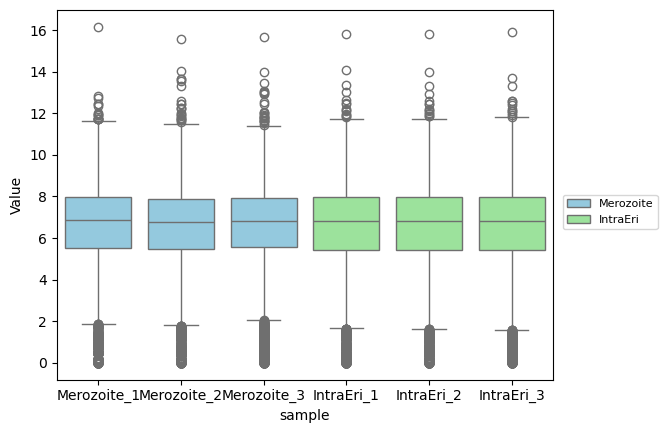

In [5]:
#now we made the large format of the data this for boxplot an density graphs 
df_logmelt_batched= counts_batched_df.melt(var_name="sample", value_name="Value") 

#add some column for identifing the to types of replicates in the rna-seq data
df_logmelt_batched["Cond"]= df_logmelt_batched["sample"].str.replace("_.$","", regex=True)

display(df_logmelt_batched)

sns.boxplot(data= df_logmelt_batched, x="sample", y="Value", hue="Cond", palette={"Merozoite": "skyblue", "IntraEri":"lightgreen"}) 

plt.legend(
    bbox_to_anchor=(1.02, 0.5), 
    loc='upper left',          
    borderaxespad=0, 
    fontsize = 8,
    title_fontsize=20
) 


### Boxplot without batch error correction

,sample,Value,Cond
0,Merozoite_1,10.338736,Merozoite
1,Merozoite_1,6.149747,Merozoite
2,Merozoite_1,6.614710,Merozoite
3,Merozoite_1,6.339850,Merozoite
4,Merozoite_1,6.727920,Merozoite
...,...,...,...
24463,IntraEri_3,12.120562,IntraEri
24464,IntraEri_3,10.108524,IntraEri
24465,IntraEri_3,10.237210,IntraEri
24466,IntraEri_3,10.255029,IntraEri


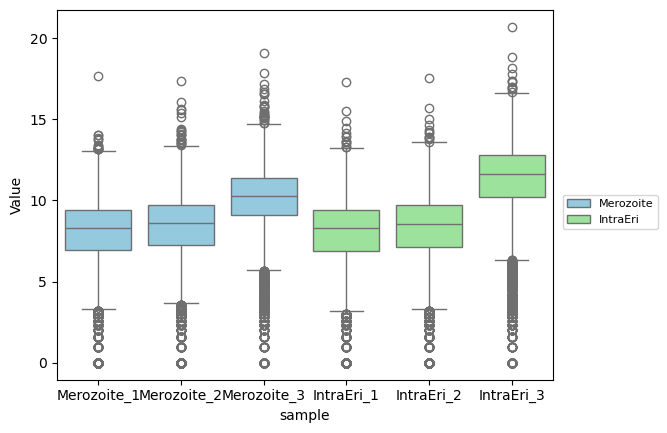

In [6]:
#now we made the large format of the data this for boxplot an density graphs 
df_logmelt= df_log.melt(var_name="sample", value_name="Value") 

#add some column for identifing the to types of replicates in the rna-seq data
df_logmelt["Cond"]= df_logmelt["sample"].str.replace("_.$","", regex=True)

display(df_logmelt) 

sns.boxplot(data= df_logmelt, x="sample", y="Value", hue="Cond", palette={"Merozoite": "skyblue", "IntraEri":"lightgreen"}) 

plt.legend(
    bbox_to_anchor=(1.02, 0.5), 
    loc='upper left',          
    borderaxespad=0, 
    fontsize = 8,
    title_fontsize=20
) 


### Density graph
This type of reprsentation help us for viewing the distribution of the count, it is helpfull for give us and idea of what counts could be noise in our analisis, i mean the reads with poorly coverage

### With batch correction

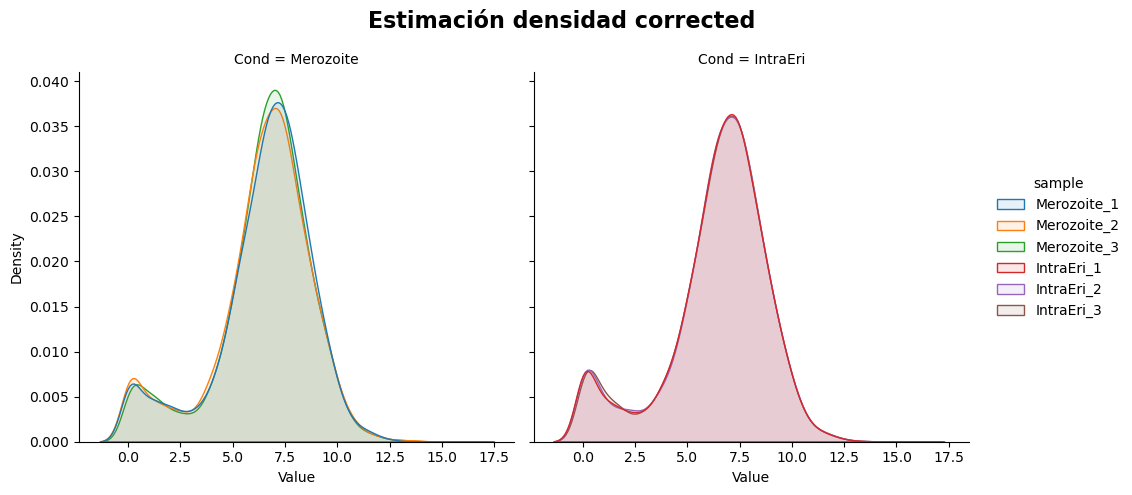

In [7]:
graf=sns.displot( data=df_logmelt_batched, x="Value", hue="sample", col= "Cond", kind="kde", fill=True, alpha= 0.1) 

graf.figure.suptitle("Estimación densidad corrected", fontsize=16, fontweight="bold") 
graf.tight_layout()
plt.show()

### Without batch error correction

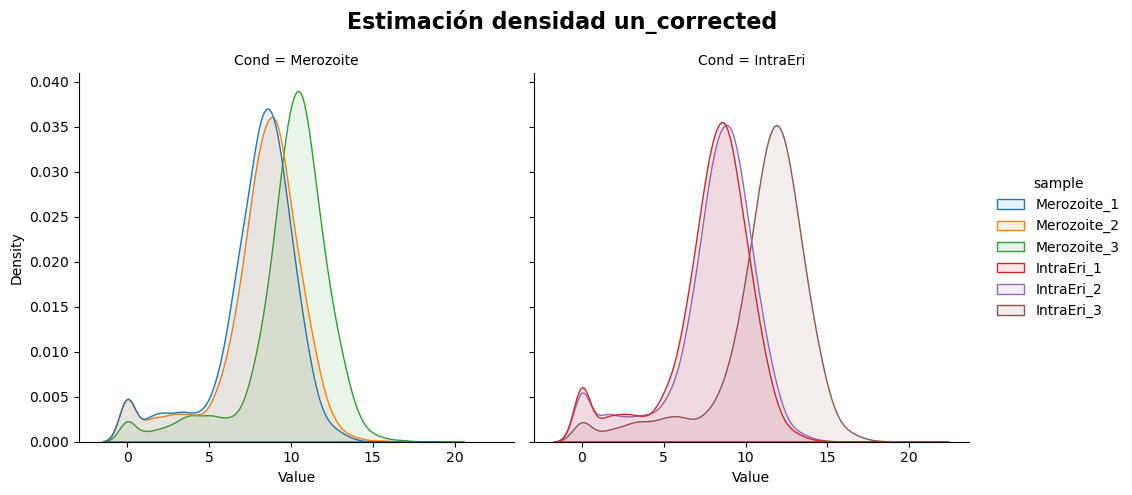

In [8]:
graf=sns.displot( data=df_logmelt, x="Value", hue="sample", col= "Cond", kind="kde", fill=True, alpha= 0.1) 

graf.figure.suptitle("Estimación densidad un_corrected", fontsize=16, fontweight="bold") 
graf.tight_layout()
plt.show()

### PCA 
The principal component analysis help us to view the clustering of our samples in function of their variations 

### PCA without bacth correction 

In [9]:

expresion_df= df_log.T 
#PCA object
pca= PCA(n_components=2) 

principal_components=pca.fit_transform(expresion_df)

#data frame with the 2 principal components 
Condiciones=df_log.columns.str.replace("_.$","", regex=True) 

pca_df=pd.DataFrame(data=principal_components, columns=["PC1", "PC2"], index=expresion_df.index)
pca_df["Condiciones"]=Condiciones 
display(pca_df)

,PC1,PC2,Condiciones
Merozoite_1,-61.296965,5.289212,Merozoite
Merozoite_2,-41.546325,9.365254,Merozoite
Merozoite_3,70.606225,26.374484,Merozoite
IntraEri_1,-64.429268,-11.552198,IntraEri
IntraEri_2,-48.429983,-12.317553,IntraEri
IntraEri_3,145.096316,-17.159200,IntraEri


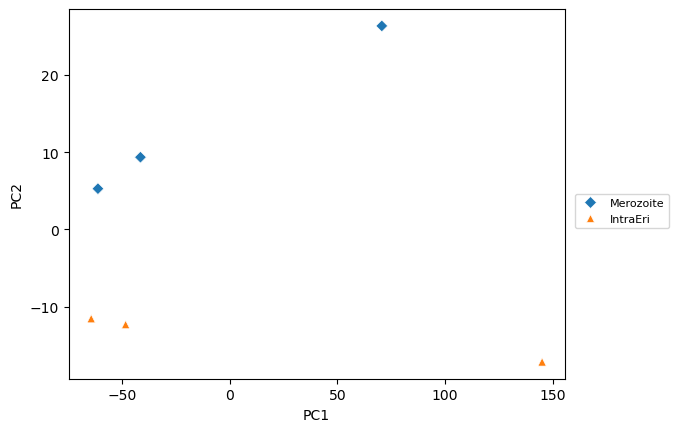

In [10]:
#We make a scaterplot for viewing the principal components 1 and 2 that explain the higher amount of variation 
sns.scatterplot(data=pca_df, 
                x="PC1", 
                y="PC2", 
                hue="Condiciones", 
                style="Condiciones",
                markers={"IntraEri": "^", "Merozoite": "D"}) 

plt.legend(
    bbox_to_anchor=(1.02, 0.5),   # posición fuera del eje,  en terminos de las coordenadas de acuerdo al borde de la grafica (esquina inferior izquierda (0,0))
    loc='upper left',           # punto de anclaje de la leyenda
    borderaxespad=0, #tamaño del recuadro 
    fontsize = 8,
    title_fontsize=20
)

plt.show() 

### PCA with batch correction

,PC1,PC2,Condiciones
Merozoite_1,5.281914,-13.267170,Merozoite
Merozoite_2,10.365339,9.545567,Merozoite
Merozoite_3,14.309530,0.386567,Merozoite
IntraEri_1,-10.458190,1.359034,IntraEri
IntraEri_2,-10.298506,1.826414,IntraEri
IntraEri_3,-9.200087,0.149588,IntraEri


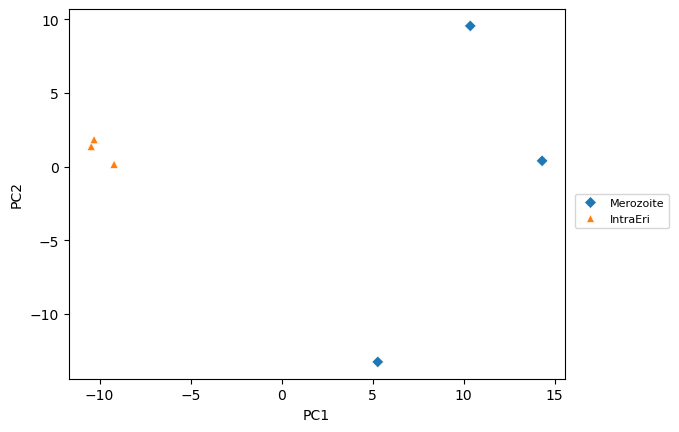

In [11]:
expresion_df= counts_batched_df.T 
#PCA object
pca_2= PCA(n_components=2) 

principal_components_2=pca_2.fit_transform(expresion_df)

#data frame with the 2 principal components 
Condiciones=counts_batched_df.columns.str.replace("_.$","", regex=True) 

pca_df=pd.DataFrame(data=principal_components_2, columns=["PC1", "PC2"], index=expresion_df.index)
pca_df["Condiciones"]=Condiciones 
display(pca_df)

#We make a scaterplot for viewing the principal components 1 and 2 that explain the higher amount of variation 
sns.scatterplot(data=pca_df, 
                x="PC1", 
                y="PC2", 
                hue="Condiciones", 
                style="Condiciones",
                markers={"IntraEri": "^", "Merozoite": "D"}) 

plt.legend(
    bbox_to_anchor=(1.02, 0.5),   # posición fuera del eje,  en terminos de las coordenadas de acuerdo al borde de la grafica (esquina inferior izquierda (0,0))
    loc='upper left',           # punto de anclaje de la leyenda
    borderaxespad=0, #tamaño del recuadro 
    fontsize = 8,
    title_fontsize=20
)

plt.show() 


## Pruebas exploracion

In [12]:
def clean_plt(fig):
    plt.tight_layout()
    plt.show()
    
    try:
        plt.close(fig)
    except: 
        print("Se mostro un grafico de densidad")
    

In [13]:
def save_plt(plt_ob, name:str)->None:
    """
    Function for saving the plots in the script in a results plt directory
    """ 
    #make sure the path already exist
    direc= os.path.join("../../results/plts")
    if not os.path.exists(direc):
        os.mkdir(direc) 
        
    plotfile=os.path.join(direc,name) 
    
    plt_ob.savefig(plotfile,      
            dpi=300,                    
            bbox_inches="tight")
    plt.tight_layout()
    try:
        plt.close(plt)
        print(f"Saving {name} plot in {plotfile}")
    except: 
        print(f"Saving {name} plot in {plotfile}")

### box plt function

In [24]:
def box_plot(data): 
    """
    Function that makes the boxplot figure 
    """
    box_plt, ax = plt.subplots(figsize=(6, 4)) 
    sns.boxplot(data= data,ax=ax, x="sample", y="Value", hue="Cond", palette={"Merozoite": "skyblue", "IntraEri":"lightgreen"})
    
    ax.set_title("Boxplot of the counts ditribuction", fontsize=14, fontweight="bold", fontstyle="italic", color="darkblue")
    ax.set_facecolor("beige")
    ax.figure.set_facecolor("mintcream")
    
    ax.legend(
        bbox_to_anchor=(1.02, 0.5), 
        loc='upper left',          
        borderaxespad=0, 
        fontsize = 8,
        title_fontsize=20,
        labelcolor="g",
        facecolor="lightblue"
    ) 
    save_plt(box_plt,"box_exploratory.png")
    
    print(type(box_plt))

### density function

In [20]:
def density_plot(data): 
    """
    Function that makes the density plot of the distribution of counts in both conditions
    """ 
    
    den_plt=sns.displot( data=data, x="Value", hue="sample", col= "Cond", kind="kde", fill=True, alpha= 0.1)
    den_plt.fig.set_facecolor("mintcream")

    conditions=["Merozoite", "Intra eritrocyte"]
    # Personalizar cada subplot
    for ax,con in zip(den_plt.axes.flat, conditions):
        ax.set_facecolor("beige")
        ax.set_title(f"Density in {con}", fontsize=12, fontweight="bold", color="darkblue")

    # Título general
    den_plt.fig.suptitle("Distribution of Expression Counts", fontsize=16, fontweight="bold", fontstyle="italic", color="darkblue")

    den_plt._legend.set_title("Samples")
    den_plt._legend.get_frame().set_facecolor("lightblue")
    den_plt._legend.get_frame().set_edgecolor("black")
    den_plt._legend.set_bbox_to_anchor((1.15, 0.5))
 
    save_plt(den_plt,"density_exploratory.png")
    print(type(den_plt))

### PCA function

In [23]:
def PCA_plot(matrix:pd.DataFrame):
    """
    Function that make a PCA plot 
    """
    
    matrix_t=matrix.T
    #PCA object
    pca= PCA(n_components=2) 

    principal_components=pca.fit_transform(matrix_t)

    #data frame with the 2 principal components 
    Condiciones=matrix.columns.str.replace("_.$","", regex=True) 

    pca_df=pd.DataFrame(data=principal_components, columns=["PC1", "PC2"], index=matrix_t.index)
    pca_df["Condiciones"]=Condiciones 
    
    PCA_plt, ax = plt.subplots(figsize=(6, 4))
    #We make a scaterplot for viewing the principal components 1 and 2 that explain the higher amount of variation 
    sns.scatterplot(data=pca_df, 
                    ax=ax,
                    x="PC1", 
                    y="PC2", 
                    hue="Condiciones", 
                    style="Condiciones",
                    markers={"IntraEri": "^", "Merozoite": "D"}
                    ) 

    ax.set_title("PCA plot of the varition in count matrix data", fontsize=14, fontweight="bold", fontstyle="italic", color="darkblue")
    ax.set_facecolor("beige")
    ax.figure.set_facecolor("mintcream")
    
    ax.legend(
        bbox_to_anchor=(1.02, 0.5), 
        loc='upper left',          
        borderaxespad=0, 
        fontsize = 8,
        title_fontsize=20,
        labelcolor="g",
        facecolor="lightblue"
    ) 
    print(type(PCA_plt))
    save_plt(PCA_plt,"PCA_exploratory.png")
    

Simular el main 

Saving box_exploratory.png plot in ../../results/plts/box_exploratory.png
<class 'matplotlib.figure.Figure'>
Saving density_exploratory.png plot in ../../results/plts/density_exploratory.png
<class 'seaborn.axisgrid.FacetGrid'>
<class 'matplotlib.figure.Figure'>
Saving PCA_exploratory.png plot in ../../results/plts/PCA_exploratory.png


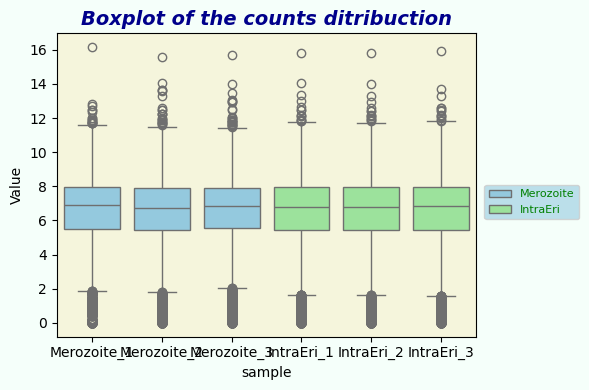

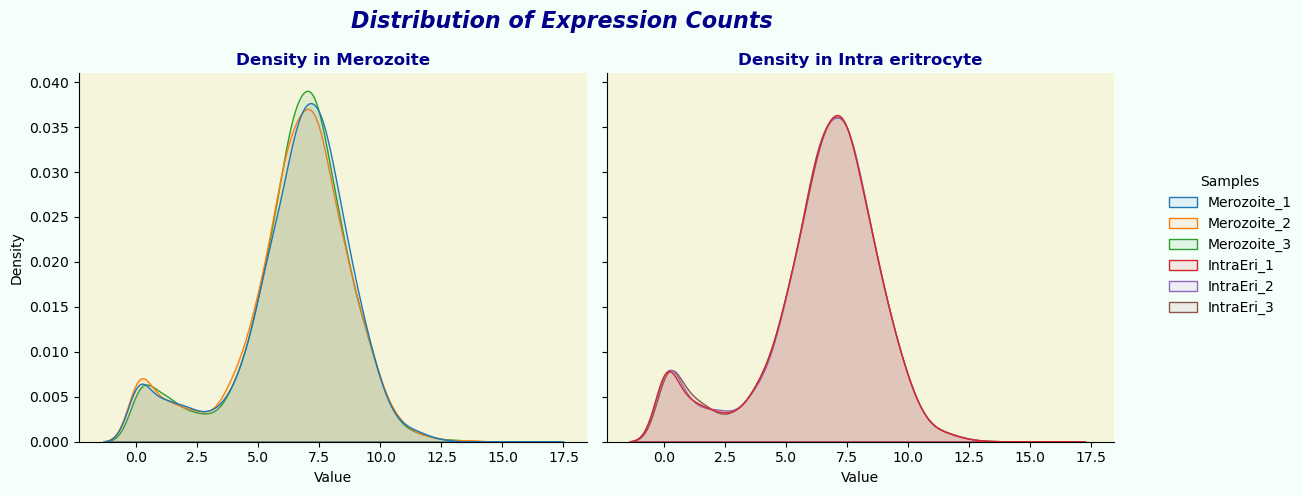

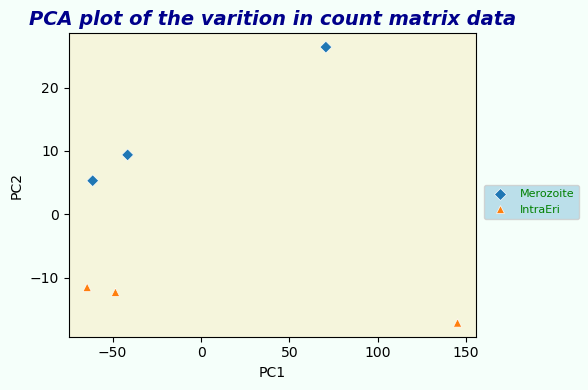

In [25]:
df_logmelt= counts_batched_df.melt(var_name="sample", value_name="Value")
#add some column for identifing the to types of replicates in the rna-seq data
df_logmelt["Cond"]= df_logmelt["sample"].str.replace("_.$","", regex=True) 

box_plot(df_logmelt)
density_plot(df_logmelt) 


PCA_plot(df_log)